# Heart Disease Diagnosis using Machine Learning

## 1. Giới thiệu bài toán

Bệnh tim là một trong những vấn đề sức khỏe nghiêm trọng và phổ biến trên thế giới.
Việc phát hiện sớm nguy cơ mắc bệnh tim có thể giúp bác sĩ và bệnh nhân đưa ra các biện pháp điều trị hoặc phòng ngừa kịp thời.

Trong dự án này, chúng ta sử dụng bộ dữ liệu Heart Disease UCI để xây dựng mô hình Machine Learning nhằm dự đoán một bệnh nhân có mắc bệnh tim hay không dựa trên các thông tin y tế như tuổi, giới tính, huyết áp, cholesterol, nhịp tim tối đa, loại đau ngực và một số chỉ số liên quan khác.

## Bối cảnh

Bộ dữ liệu gồm thông tin y tế của các bệnh nhân được thu thập từ nhiều nguồn khác nhau.
Mỗi bệnh nhân có nhiều thuộc tính như tuổi, giới tính, loại đau ngực, huyết áp khi nghỉ, cholesterol, đường huyết, kết quả điện tâm đồ, nhịp tim tối đa và một số thông tin lâm sàng khác.

Biến mục tiêu của bài toán là `num`, thể hiện mức độ mắc bệnh tim của bệnh nhân.

## Tầm quan trọng

Dự đoán bệnh tim bằng Machine Learning có thể hỗ trợ quá trình chẩn đoán ban đầu, giúp phát hiện các bệnh nhân có nguy cơ cao.
Điều này có ý nghĩa trong việc hỗ trợ bác sĩ ra quyết định, tiết kiệm thời gian kiểm tra và nâng cao hiệu quả chăm sóc sức khỏe.

## Mục tiêu dự án

Mục tiêu của dự án là xây dựng mô hình phân loại để dự đoán bệnh nhân có mắc bệnh tim hay không.

Trong bộ dữ liệu gốc, cột `num` có các giá trị từ 0 đến 4:
- `num = 0`: Không mắc bệnh tim
- `num > 0`: Có mắc bệnh tim

Do đó, bài toán sẽ được chuyển thành bài toán phân loại nhị phân:
- `0`: Không mắc bệnh tim
- `1`: Có mắc bệnh tim

## Phương pháp tiếp cận

Đây là bài toán phân loại nhị phân (Binary Classification).
Dự án sẽ thử nghiệm và so sánh ba mô hình Machine Learning:

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest

Các mô hình sẽ được đánh giá bằng các thước đo như Accuracy, Precision, Recall, F1-score và Confusion Matrix.

In [218]:
# Import các thư viện cần thiết cho dự án
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập hiển thị
pd.set_option('display.max_columns', None)

In [219]:
# Đọc dữ liệu

df = pd.read_csv('/content/drive/MyDrive/Võ Như Chiến/Python-DUT/Project-ML/heart_disease_uci.csv')

# Hiển thị 5 dòng đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2. Mô tả dữ liệu

Bộ dữ liệu được sử dụng trong dự án là Heart Disease UCI Dataset.
Dataset chứa thông tin y tế của các bệnh nhân, bao gồm các đặc trưng như tuổi, giới tính, loại đau ngực, huyết áp, cholesterol, nhịp tim tối đa, kết quả điện tâm đồ và một số chỉ số liên quan khác.

Mục tiêu của bài toán là dự đoán bệnh nhân có mắc bệnh tim hay không dựa trên các thông tin y tế này.

Trong dataset, cột `num` là biến mục tiêu:
- `num = 0`: Không mắc bệnh tim
- `num > 0`: Có mắc bệnh tim

Ban đầu, cột `num` có nhiều mức độ bệnh từ 0 đến 4.
Trong dự án này, ta chuyển bài toán thành phân loại nhị phân:
- 0: Không mắc bệnh tim
- 1: Có mắc bệnh tim

In [220]:
# Kiểm tra số dòng và số cột của dữ liệu

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

Số dòng: 920
Số cột: 16


In [221]:
# Xem danh sách các cột trong dataset

for col in df.columns:
    print(col)

id
age
sex
dataset
cp
trestbps
chol
fbs
restecg
thalch
exang
oldpeak
slope
ca
thal
num


Các cột trong dataset bao gồm:

- `id`: Mã định danh duy nhất của từng bệnh nhân.
- `age`: Tuổi của bệnh nhân.
- `sex`: Giới tính của bệnh nhân.
- `dataset`: Nguồn hoặc nơi thu thập dữ liệu.
- `cp`: Loại đau ngực.
- `trestbps`: Huyết áp khi nghỉ.
- `chol`: Lượng cholesterol trong máu.
- `fbs`: Đường huyết lúc đói có lớn hơn 120 mg/dl hay không.
- `restecg`: Kết quả điện tâm đồ khi nghỉ.
- `thalch`: Nhịp tim tối đa đạt được.
- `exang`: Có đau thắt ngực do vận động hay không.
- `oldpeak`: Độ chênh ST khi vận động so với lúc nghỉ.
- `slope`: Độ dốc của đoạn ST khi đạt đỉnh vận động.
- `ca`: Số lượng mạch máu chính được phát hiện qua fluoroscopy.
- `thal`: Tình trạng Thalassemia.
- `num`: Biến mục tiêu, thể hiện tình trạng mắc bệnh tim.

Trong đó, `num` là biến cần dự đoán.  
Các cột còn lại sẽ được sử dụng làm đặc trưng đầu vào cho mô hình, ngoại trừ `id` vì đây chỉ là mã định danh bệnh nhân.

In [222]:
# Xem thông tin tổng quan: tên cột, số giá trị không null và kiểu dữ liệu

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


Note:

- Dataset có **920 dòng** và **16 cột**.  
Các cột trong dữ liệu gồm cả biến số và biến phân loại.
- Một số cột như `id`, `age`, `sex`, `dataset`, `cp`, `num` không bị thiếu dữ liệu.  
- Tuy nhiên, nhiều cột khác có missing values, đặc biệt là `ca`, `thal` và `slope`.
- Điều này cho thấy dữ liệu chưa hoàn toàn sạch.  

Do đó, ở bước tiền xử lý, ta cần xử lý giá trị thiếu, mã hóa biến phân loại và chuẩn hóa dữ liệu trước khi đưa vào mô hình Machine Learning.

In [223]:
# Phân loại các cột theo ý nghĩa thực tế

numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

categorical_features = [
    'sex', 'dataset', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

target = 'num'

id_col = 'id'

In [224]:
# Thống kê mô tả cho các biến số thực sự

df[numeric_features].describe()

,age,trestbps,chol,thalch,oldpeak
count,920.000000,861.000000,890.000000,865.000000,858.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788
std,9.424685,19.066070,110.780810,25.926276,1.091226
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,175.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000
75%,60.000000,140.000000,268.000000,157.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


In [225]:
# Thống kê mô tả cho các biến phân loại

df[categorical_features].astype('object').describe()

,sex,dataset,cp,fbs,restecg,exang,slope,ca,thal
count,920,920,920,830,918,865,611,309.0,434
unique,2,4,4,2,3,2,3,4.0,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,0.0,normal
freq,726,304,496,692,551,528,345,181.0,196


Ở bước này, ta tách dữ liệu thành hai nhóm chính để thống kê chính xác hơn:

- **Biến số thực sự**: gồm `age`, `trestbps`, `chol`, `thalch`, `oldpeak`
- **Biến phân loại**: gồm `sex`, `dataset`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`

Đối với các biến số, bảng thống kê cho biết các giá trị như trung bình, độ lệch chuẩn, giá trị nhỏ nhất, lớn nhất và các phân vị.  
Ví dụ, tuổi trung bình của bệnh nhân khoảng **53.5 tuổi**, huyết áp nghỉ trung bình khoảng **132 mm Hg**, và cholesterol trung bình khoảng **199 mg/dl**.

Đối với các biến phân loại, bảng thống kê cho biết số lượng giá trị không bị thiếu, số lượng nhóm khác nhau, giá trị xuất hiện nhiều nhất và tần suất của giá trị đó.  
Ví dụ, giới tính xuất hiện nhiều nhất là **Male**, nguồn dữ liệu phổ biến nhất là **Cleveland**, và loại đau ngực phổ biến nhất là **asymptomatic**.

Việc tách biến số và biến phân loại giúp ta hiểu dữ liệu đúng hơn, vì một số cột như `ca` tuy được lưu dưới dạng số nhưng về ý nghĩa lại là biến phân loại/thứ bậc.

## 4. Prepare the Data for Machine Learning

Sau bước EDA, ta chuẩn bị dữ liệu cho mô hình Machine Learning.

Ở bước này, ta sẽ:
- Chuyển bài toán thành binary classification
- Tạo biến target từ cột `num`
- Tách dữ liệu thành features `X` và label `y`
- Chia dữ liệu thành training set và test set

Lưu ý: các bước xử lý như fill missing value, encoding và scaling sẽ được đưa vào pipeline để tránh data leakage.

In [226]:
df_model = df.copy()

df_model['target'] = df_model['num'].apply(lambda x: 0 if x == 0 else 1)

df_model['trestbps'] = df_model['trestbps'].replace(0, np.nan)
df_model['chol'] = df_model['chol'].replace(0, np.nan)
df_model.loc[df_model['oldpeak'] < 0, 'oldpeak'] = np.nan

df_model[['num', 'target']].head()

,num,target
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [227]:
X = df_model.drop(columns=['id', 'dataset', 'num', 'target'])
y = df_model['target']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (920, 13)
y shape: (920,)


## 5. Train/Test Split

Ta chia dữ liệu thành training set và test set.

Training set dùng để huấn luyện mô hình và cross-validation.  
Test set chỉ dùng một lần cuối cùng để đánh giá mô hình sau khi đã chọn và tinh chỉnh xong.

In [228]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (736, 13)
X_test: (184, 13)
y_train: (736,)
y_test: (184,)


## 6. Preprocessing Pipeline

Ta xây dựng preprocessing pipeline để xử lý dữ liệu trước khi đưa vào mô hình.

Pipeline gồm:
- Numeric features: xử lý missing value bằng median, sau đó chuẩn hóa bằng StandardScaler
- Categorical features: xử lý missing value bằng mode, sau đó mã hóa bằng OneHotEncoder

Pipeline chỉ được fit trên training set. Test set chỉ được transform bằng pipeline đã học từ training set.

In [229]:
numeric_features = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak'
]

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal'
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [230]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

## 8. Select and Train Models

Ta sẽ thử 3 mô hình:

- Logistic Regression: baseline model, đơn giản và dễ giải thích
- KNN: mô hình dựa trên khoảng cách
- Random Forest: ensemble model, có khả năng học quan hệ phi tuyến tốt hơn

Mỗi model sẽ được gắn với cùng một preprocessing pipeline để đảm bảo xử lý dữ liệu nhất quán.

In [231]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features='sqrt',
        class_weight=None,
        random_state=42
    )
}

## 9. Better Evaluation Using Cross-Validation

Ta dùng K-Fold Cross-Validation trên training set để đánh giá mô hình ổn định hơn.

Test set chưa được sử dụng ở bước này.  
Test set chỉ dùng sau khi đã chọn được mô hình cuối cùng.

In [232]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# StratifiedKFold giúp giữ tỷ lệ class 0 và 1 tương đối đều ở mỗi fold
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    scores = cross_validate(
        clf,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=True
    )

    cv_results.append({
        'Model': model_name,
        'Train Accuracy': scores['train_accuracy'].mean(),
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1': scores['test_f1'].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Train Accuracy,CV Accuracy,CV Precision,CV Recall,CV F1
0,Logistic Regression,0.826088,0.804394,0.814750,0.844986,0.827166
1,KNN,0.861071,0.815242,0.814488,0.867299,0.839188
2,Random Forest,0.855980,0.803024,0.808728,0.852424,0.827885


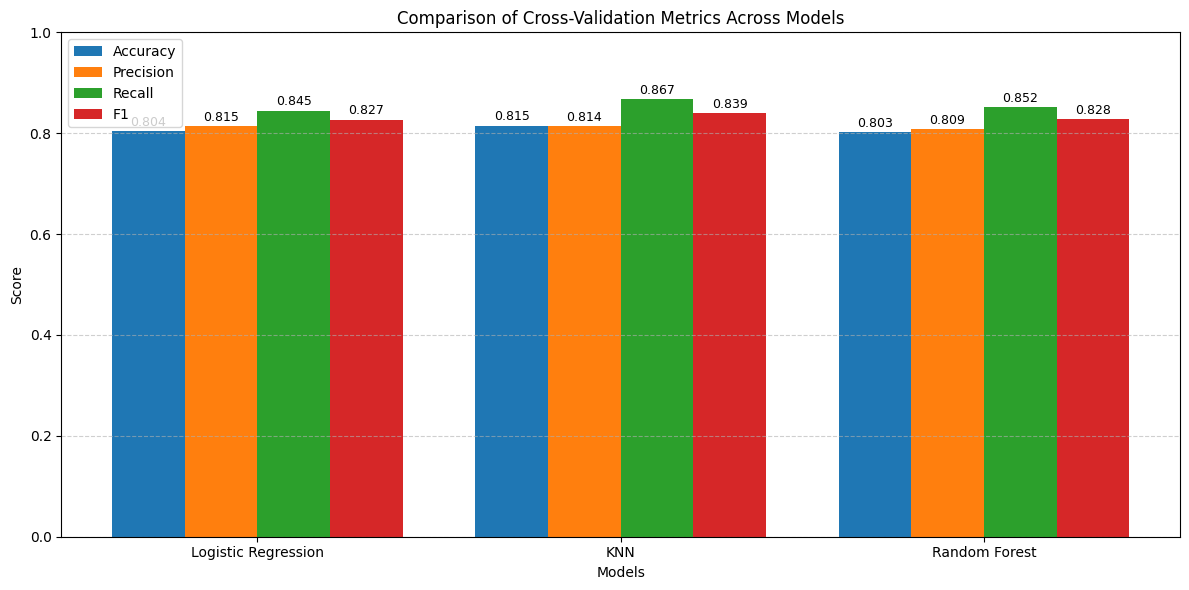

In [233]:
# Chọn 4 metric cần so sánh
metrics = ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1']

# Lấy tên model
models_name = cv_results_df['Model']

# Tạo vị trí trên trục x
x = np.arange(len(models_name))
width = 0.2

plt.figure(figsize=(12, 6))

# Vẽ từng metric
for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        cv_results_df[metric],
        width,
        label=metric.replace('CV ', '')
    )

# Trang trí biểu đồ
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Cross-Validation Metrics Across Models')
plt.xticks(x, models_name)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị giá trị trên đầu cột với 3 chữ số thập phân
for i, metric in enumerate(metrics):
    for j, value in enumerate(cv_results_df[metric]):
        plt.text(
            x[j] + (i - 1.5) * width,
            value + 0.01,
            f'{value:.3f}',
            ha='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

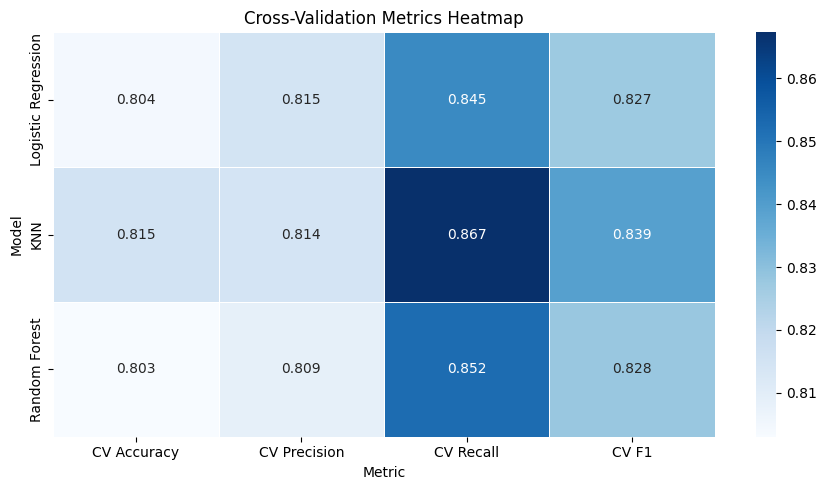

In [234]:
# Chuẩn bị dữ liệu cho heatmap
heatmap_data = cv_results_df.set_index('Model')[
    ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1']
]

plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Cross-Validation Metrics Heatmap')
plt.ylabel('Model')
plt.xlabel('Metric')

plt.tight_layout()
plt.show()

## 10. Đánh giá các mô hình trên tập test

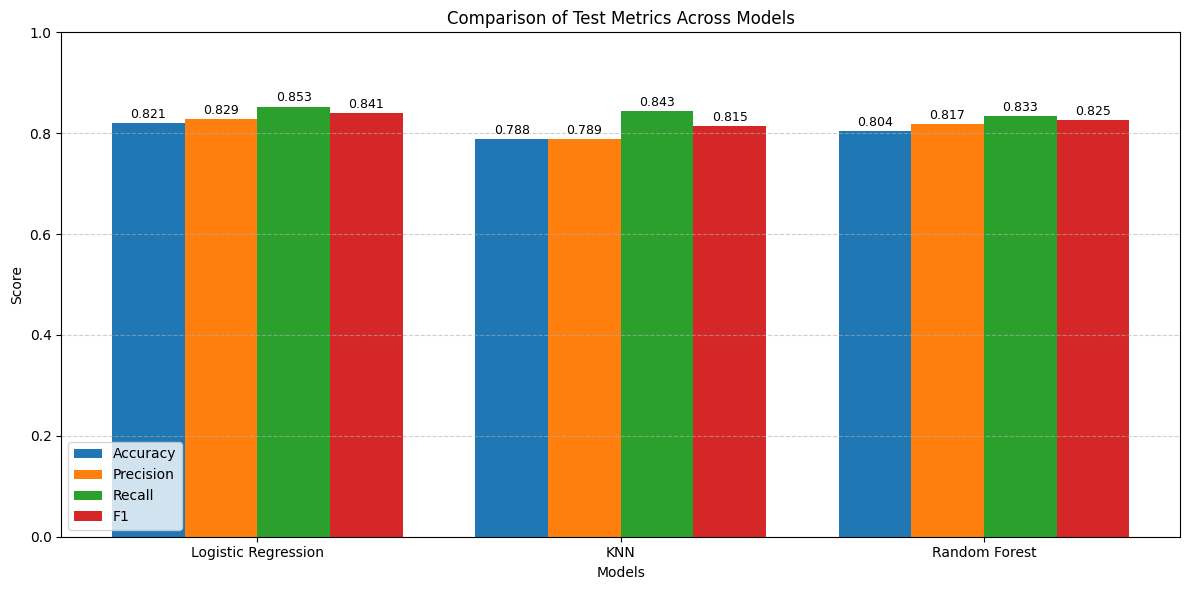

In [235]:
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']

models_name = test_results_df['Model']
x = np.arange(len(models_name))
width = 0.2

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        test_results_df[metric],
        width,
        label=metric.replace('Test ', '')
    )

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comparison of Test Metrics Across Models')
plt.xticks(x, models_name)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Hiển thị giá trị trên đầu cột với 3 chữ số thập phân
for i, metric in enumerate(metrics):
    for j, value in enumerate(test_results_df[metric]):
        plt.text(
            x[j] + (i - 1.5) * width,
            value + 0.01,
            f'{value:.3f}',
            ha='center',
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [236]:
for model_name, clf in trained_pipelines.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    y_pred = clf.predict(X_test)

    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.78      0.80        82
           1       0.83      0.85      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184

KNN
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        82
           1       0.79      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.79      0.79       184

Random Forest
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        82
           1       0.82      0.83      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80   